# Main

In [1]:
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'


# cosmology
import pyccl as ccl
#from astropy.io import fits
import yaml
#import sacc
import time

# Generic
import pandas as pd
import numpy as np
import scipy
from itertools import islice, cycle
import math
import sys
from scipy.integrate import odeint
#from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
#import baccoemu
import subprocess
import multiprocessing


# Generate data sets
#from sklearn.datasets import make_blobs
#import sklearn
#print(sklearn.__version__) # should be 1.3.2

# PCA
#from sklearn.preprocessing import StandardScaler
#from sklearn.decomposition import PCA

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.patches as mpatches
import matplotlib
#import seaborn as sns

# MCMC
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
#import corner
from IPython.display import display, Math
from multiprocessing import Pool, cpu_count
#from tqdm import tqdm
import gc

# Profiling
import cProfile
import pstats
from IPython.display import HTML

# nDGP NL and lin Pk
from nDGPemu import BoostPredictor

# f(R) emu (eMANTIS)
from emantis import FofrBoost

# Initialise and emulator instance.
emu_fR = FofrBoost()

In [2]:
!which python

/home/c2042999/PCA_env/3.8.10/bin/python


In [3]:
print(emcee.__version__)
print(ccl.__version__)

3.1.6
3.2.1


In [4]:
from LikelihoodFuncts_PCADR_muSigma_minimal import *

Loading model and related data


/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.24.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# Define cosmology
cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)


In [7]:
#### Define log likelihood #####

#### Define log likelihood #####
def log_likelihood(theta, Data, L_ch_inv):
    Omega_c, mu0, A_s1e9, h = theta
    #h = cosmo_universe["h"]
    #A_s = cosmo_universe["A_s"]
    A_s = A_s1e9*1e-9
    #n_s = cosmo_universe["n_s"]
    MGparams = [0.2,1e-4,1.0,mu0, 0.0]

    cosmo = ccl.Cosmology(Omega_c = Omega_c,
                      Omega_b = 0.0222383/h**2,
                      h = h,
                      n_s = 0.9626,
                      A_s = A_s)

    return loglikelihood(Data, cosmo, MGparams, L_ch_inv)

#### Get Planck priors #####
sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)
#### Define log prior #####
def log_prior(theta):
    Omega_c, mu0, A_s1e9, h = theta
    
    #flat priors
    if not (0.28 < Omega_c + 0.0222383/h**2 < 0.36 and -1.5 < mu0 < 1.5 \
            and 1.7 < A_s1e9 < 2.5 and 0.61 < h < 0.73):
        return -np.inf
    else:
        return 0.0


In [1]:

npzfile = np.load("Data_storage_GR.npz")

C_ell_data_mock = [npzfile['C_ell_data'][:195],npzfile['ell_data'][:195],npzfile['z'],npzfile['Binned_distribution_source'],\
                    npzfile['Binned_distribution_lens'],20,1478.5,13]
Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]

# L_choleski_inv = np.matrix(npzfile['L_ch_inv'])[:195,:195]

#################

# Get covariance from scratch

covfile = np.genfromtxt("Y1_3x2pt_clusterN_clusterWL_cov")

shear_SRD = np.zeros((705,705))
ell_test_SRD = np.zeros(705)

for i in range(0,covfile.shape[0]):
    shear_SRD[int(covfile[i,0]),int(covfile[i,1])] = covfile[i,8]+covfile[i,9] # non-gauss
    shear_SRD[int(covfile[i,1]),int(covfile[i,0])] = covfile[i,8]+covfile[i,9] # non-gauss
    if int(covfile[i,0]) == int(covfile[i,1]):
        ell_test_SRD[int(covfile[i,0])] = covfile[i,2]

del covfile
SRD_compare = shear_SRD[:540,:540].copy()

idx = 0

bins_SRD = 20

for j in range(27):
    for i in range(bins_SRD):
        if i >= 13:
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 0)
            SRD_compare = np.delete(SRD_compare, j*bins_SRD + i - idx, 1)
            idx += 1

covariance_uncut = np.matrix(SRD_compare)

L_choleski_inv = np.matrix(np.linalg.inv(np.linalg.cholesky(covariance_uncut[:195,:195])))

z = npzfile['z']


NameError: name 'np' is not defined

In [ ]:
"""Test C_kk(ell) function"""

binned_ell = bin_ell_kk(20, 1478.5, 13, Binned_distribution_source)
"""nDGP"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,0,0,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,0,0,0,0], linear=False, gravity_model="nDGP"), tracer1_type="k", tracer2_type="k")

print("time1 = ", time.time() - start)

ell_testdata = testdata[0]
D_testdata_kk = testdata[1]

D_testdata_kk = (np.array(D_testdata_kk)).flatten()

start = time.time()
testdata_lin = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,0,0,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_lin_universe,interp_fR_Pk,cosmo_universe, [0.2,0,0,0,0], linear=True, gravity_model="nDGP"),tracer1_type="k", tracer2_type="k")

print("time2 = ", time.time() - start)

D_testdata_lin_kk = testdata_lin[1]
D_testdata_lin_kk = (np.array(D_testdata_lin_kk)).flatten()

del testdata, testdata_lin

"""fR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata_fR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-4,1,0,0], linear=False, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

print("time3 = ", time.time() - start)

ell_testdata_fR = testdata_fR[0]
D_testdata_kk_fR = testdata_fR[1]

D_testdata_kk_fR = (np.array(D_testdata_kk_fR)).flatten()

start = time.time()

testdata_lin_fR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_lin_universe,interp_fR_Pk,cosmo_universe,[0.2,1e-4,1,0,0], linear=True, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

print("time4 = ", time.time() - start)

D_testdata_lin_kk_fR = testdata_lin_fR[1]
D_testdata_lin_kk_fR = (np.array(D_testdata_lin_kk_fR)).flatten()

del testdata_fR, testdata_lin_fR

"""GR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata_GR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                P_delta2D_GR_nl_universe,tracer1_type="k", tracer2_type="k")
print("time5 = ", time.time() - start)

D_testdata_GR_kk = testdata_GR[1]
D_testdata_GR_kk = (np.array(D_testdata_GR_kk)).flatten()

start = time.time()
testdata_GR_lin = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                P_delta2D_GR_lin_universe,tracer1_type="k", tracer2_type="k")
print("time6 = ", time.time() - start)

D_testdata_GR_lin_kk = testdata_GR_lin[1]
D_testdata_GR_lin_kk = (np.array(D_testdata_GR_lin_kk)).flatten()

del testdata_GR, testdata_GR_lin

(195,)


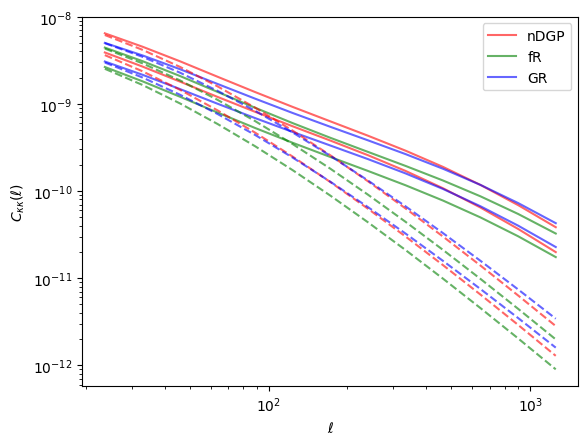

In [12]:
"""Plots: Test C_kk(ell) function"""

ell_bin_number = 13
print(D_testdata_kk.shape)


for j in range(2):
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_kk[j*ell_bin_number:(j+1)*ell_bin_number], "r", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_GR_kk[j*ell_bin_number:(j+1)*ell_bin_number], "g", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_kk_fR[j*ell_bin_number:(j+1)*ell_bin_number], "b", alpha= 0.6)
for j in range(2):
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_lin_kk[j*ell_bin_number:(j+1)*ell_bin_number], "r--", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_GR_lin_kk[j*ell_bin_number:(j+1)*ell_bin_number], "g--", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_lin_kk_fR[j*ell_bin_number:(j+1)*ell_bin_number], "b--", alpha= 0.6)


plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\kappa\kappa}(\ell)$')
plt.legend(["nDGP", "fR","GR"])
plt.xscale('log')
plt.yscale('log')
plt.show()

<>:7: DeprecationWarning: invalid escape sequence '\e'
<>:8: DeprecationWarning: invalid escape sequence '\e'
<>:7: DeprecationWarning: invalid escape sequence '\e'
<>:8: DeprecationWarning: invalid escape sequence '\e'
/tmp/ipykernel_1285922/4073861087.py:7: DeprecationWarning: invalid escape sequence '\e'
  plt.xlabel("$\ell$",fontsize=16)
/tmp/ipykernel_1285922/4073861087.py:8: DeprecationWarning: invalid escape sequence '\e'
  plt.ylabel("$C^{ij}_{AB}(\ell)$",fontsize=16)


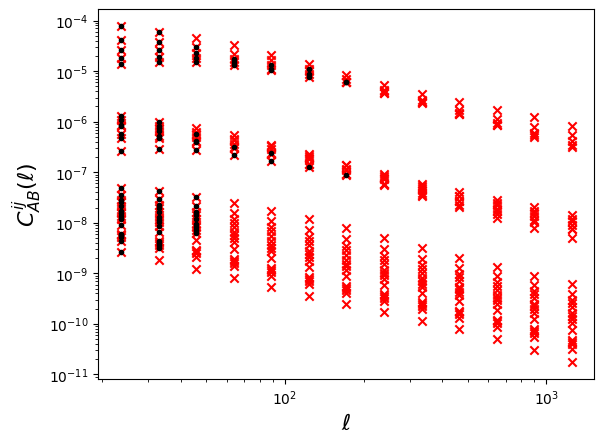

In [13]:
plt.scatter(npzfile['ell_data'],npzfile['C_ell_data'], color="r", marker='x')

for i in range(351):
    if gauss_invcov_rotated[0,i] !=0:
        plt.scatter(npzfile['ell_data'][i],npzfile['C_ell_data'][i], color="k", marker='.')

plt.xlabel("$\ell$",fontsize=16)
plt.ylabel("$C^{ij}_{AB}(\ell)$",fontsize=16)
plt.xscale("log")
plt.yscale("log")
#plt.savefig("LinearScaleCuts.pdf", bbox_inches='tight')


(351, 351)


/home/c2042999/PCA_project/Parameter_inference_GR/LikelihoodFuncts_PCADR_muSigma.py:1485: RuntimeWarning: invalid value encountered in divide
  return cov/np.outer(sig, sig)


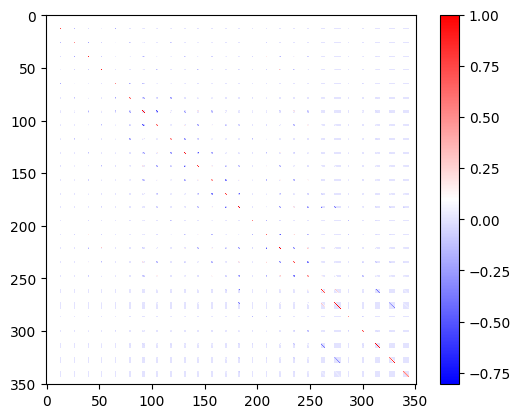

In [14]:
print(gauss_invcov_rotated.shape)
plt.imshow(cov2corr(gauss_invcov_rotated), origin='upper',  cmap='bwr')

plt.colorbar()
plt.show()

# Main

In [9]:
#### Define log probability #####
def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, C_ell_data_mock, L_choleski_inv)
    

In [10]:
print(log_probability([0.25,0.0,2.1,0.7]))

-6.861376653890919


In [11]:
# Set the random seed for reproducibility
np.random.seed(10)

n_steps = 15000
chain_len = 100
converged = False
nwalkers = 80

print(cpu_count())
# Initialize the walkers

# Initialize walkers
Omega_c_est = 0.27
h_est = 0.7
A_s1e9_est = 2.1
mu0_est = 0.1
# Random initial positions of walkers
pos = [Omega_c_est, mu0_est, A_s1e9_est, h_est] + 1e-3 * np.random.randn(nwalkers, 4)

nwalkers, ndim = pos.shape
print(nwalkers, ndim)

# Create the output directory and set up the HDF5 backend
mcmc_dir = "mcmc"
filename = mcmc_dir + "/mcmc_GR_muSigma_PCACuts_minimal.h5"
backend = emcee.backends.HDFBackend(filename)

# Optionally reset the backend if starting a new run
#backend.reset(nwalkers, ndim)

with Pool(80) as pool:
    sampler_PCA = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend, pool=pool)
    pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos

    while not converged:
        gc.collect(generation=0)
        sampler_PCA.run_mcmc(pos, chain_len, progress=True, store=True)
        
        # Clear references in the worker pool
        pool.close()
        pool.join()
        del pool  # Ensure the pool object is removed
        gc.collect()  # Collect any lingering garbage
        pool = Pool(80)
        sampler_PCA.pool = pool
        pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos
        
        # Check convergence
        try:
            tau = sampler_PCA.get_autocorr_time(tol=0)
            converged = np.all(tau * 100 < sampler_PCA.iteration)
        except emcee.autocorr.AutocorrError:
            pass

80
80 4


 81%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                           | 81/100 [07:21<01:43,  5.45s/it]Process ForkPoolWorker-55:


emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:

Process ForkPoolWorker-32:
Process ForkPoolWorker-10:
Process ForkPoolWorker-27:
Process ForkPoolWorker-25:
Process ForkPoolWorker-44:


emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:

...

KeyboardInterrupt


KeyboardInterrupt


  exception:











  exception:
  exception:  exception:  exception:

  exception:
  exception:  exception:{}  kwargs:
  exception:
  exception:  exception:

  exception:  exception:
{}  exception:
 
  exception:








{}
  exception:
  exception:


  exception:

  kwargs:   exception:{}

  exception:



Process ForkPoolWorker-4:
Process ForkPoolWorker-78:
Process ForkPoolWorker-67:
Process ForkPoolWorker-45:
Process ForkPoolWorker-58:
Process ForkPoolWorker-62:
Process ForkPoolWorker-8:
Process ForkPoolWorker-76:
Process ForkPoolWorker-11:
Process ForkPoolWorker-63:
Process ForkPoolWorker-35:
Process ForkPoolWorker-47:
Process ForkPoolWorker-26:
Process ForkPoolWorker-18:
Process ForkPoolWorker-3:
Process ForkPoolWorker-21:
Process ForkPoolWorker-75:
Process ForkPoolWorker-1:
Process ForkPoolWorker-17:
Process ForkPoolWorker-2:
Process ForkPoolWorker-12:
Process ForkPoolWorker-9:
Process ForkPoolWorker-16:
Process ForkPoolWorker-79:
Process ForkPoolWorker-80:
Process ForkPoolWorker-20:
Process ForkPoolWorker-60:
Process ForkPoolWorker-73:


KeyboardInterrupt: 